## IRFL dataset - testing

In [1]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from datasets import load_dataset
import json
import re
from PIL import Image, ImageFilter

import torch
from src.utils.irfl_augmentations import ImageAugConfig, make_definition_augmentation_function, make_text_augmentation_function, make_image_augmentation_function
from src.utils.irfl_dataset import IRFLDataset


datasets_path = "../data/irfl/datasets/"

### Download some necessary packages

In [1]:
!pip install transformers --quiet
!pip install -U datasets --quiet
!pip install pip install tqdm --quiet
!pip install fsspec==2023.6.0 --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires numpy>=1.26.0, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.24.4 which is incompatible.
ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.9.1 requires torch==2.9.1, but you have torch 2.2.0a0+81ea7a4 which is incompatible.


### Load data from HF

In [ ]:

IRFL_idioms_dataset_path = os.path.join(datasets_path, "IRFL_idioms_dataset.csv")
IRFL_metaphors_dataset_path = os.path.join(datasets_path, "IRFL_metaphors_dataset.csv")
IRFL_similes_dataset_path = os.path.join(datasets_path, "IRFL_similes_dataset.csv")


# read the datasets from the csv files
idioms_df = pd.read_csv(IRFL_idioms_dataset_path)
metaphors_df = pd.read_csv(IRFL_metaphors_dataset_path)
similes_df = pd.read_csv(IRFL_similes_dataset_path)


# load task datasets form huggingface and save them as csv files in the datasets folder
def load_and_save_dataset(dataset_name, subset, split, save_path):
    dataset = load_dataset(dataset_name, subset, split=split)
    df = pd.DataFrame(dataset)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    print(f"Saving dataset to {save_path}")
    df.to_csv(save_path, index=False)
    return df


# load and save the datasets
idioms_detect_df = load_and_save_dataset("lampent/IRFL", "idiom-detection-task","test", datasets_path + "IRFL_idioms_dataset_detect_task.csv")
idioms_retrieve_df = load_and_save_dataset("lampent/IRFL", "idiom-retrieval-task","test", datasets_path + "IRFL_idioms_dataset_retrieve_task.csv")
metaphors_detect_df = load_and_save_dataset("lampent/IRFL", "metaphor-detection-task", "test", datasets_path + "IRFL_metaphors_dataset_detect_task.csv")
metaphors_retrieve_df = load_and_save_dataset("lampent/IRFL", "metaphor-retrieval-task", "test", datasets_path + "IRFL_metaphors_dataset_retrieve_task.csv")
similes_detect_df = load_and_save_dataset("lampent/IRFL", "simile-detection-task", "test", datasets_path + "IRFL_similes_dataset_detect_task.csv")
similes_retrieve_df = load_and_save_dataset("lampent/IRFL", "simile-retrieval-task", "test", datasets_path + "IRFL_similes_dataset_retrieve_task.csv")

Saving dataset to ../data/irfl/datasets/IRFL_idioms_dataset_detect_task.csv
Saving dataset to ../data/irfl/datasets/IRFL_idioms_dataset_retrieve_task.csv
Saving dataset to ../data/irfl/datasets/IRFL_metaphors_dataset_detect_task.csv
Saving dataset to ../data/irfl/datasets/IRFL_metaphors_dataset_retrieve_task.csv
Saving dataset to ../data/irfl/datasets/IRFL_similes_dataset_detect_task.csv
Saving dataset to ../data/irfl/datasets/IRFL_similes_dataset_retrieve_task.csv


### Save complete dataset {idioms, metaphors, simile}

In [4]:
complete_datasets = pd.concat([idioms_df, metaphors_df, similes_df], ignore_index=True)
complete_datasets_path = os.path.join(datasets_path, "IRFL_complete_datasets.csv")
complete_datasets.to_csv(complete_datasets_path, index=False)
print(f"Complete dataset saved to {complete_datasets_path}")

Complete dataset saved to ../data/irfl/datasets/IRFL_complete_datasets.csv


### Complete detection task dataset

In [79]:
complete_detection_task_datasets = pd.concat([idioms_detect_df, metaphors_detect_df, similes_detect_df], ignore_index=True)
complete_detection_task_datasets_path = os.path.join(datasets_path, "IRFL_complete_detection_task_datasets.csv")
complete_detection_task_datasets.to_csv(complete_detection_task_datasets_path, index=False)
print(f"Complete detection task dataset saved to {complete_detection_task_datasets_path}")

Complete detection task dataset saved to ../data/irfl/datasets/IRFL_complete_detection_task_datasets.csv


### Complete retrieval task dataset

In [89]:
complete_retrieval_task_datasets = pd.concat([idioms_retrieve_df, metaphors_retrieve_df, similes_retrieve_df], ignore_index=True)
complete_retrieval_task_datasets_path = os.path.join(datasets_path, "IRFL_complete_retrieval_task_datasets.csv")
complete_retrieval_task_datasets.to_csv(complete_retrieval_task_datasets_path, index=False)
print(f"Complete retrieval task dataset saved to {complete_retrieval_task_datasets_path}")

Complete retrieval task dataset saved to ../data/irfl/datasets/IRFL_complete_retrieval_task_datasets.csv


In [13]:
# extract only rows where the category of the image is 'Figurative' and keep only the columns where all entries are not null
cols = ['phrase', 'category', 'source', 'uuid', 'figurative_type', 'definition']
complete_datasets_fig_df = complete_datasets[complete_datasets['category'] == 'Figurative'][cols] #.dropna(how='any')
unique_phrases = complete_datasets_fig_df['phrase'].nunique()
print(f"Number of unique figurative phrases: {unique_phrases}")


# keep only the following columns for the complete detect task dataset
cols_detect = ['distractors', 'answer', 'phrase', 'figurative_type']
complete_detection_task_datasets_fig_df = complete_detection_task_datasets[cols_detect].dropna(how='any')
unique_phrases_detect = complete_detection_task_datasets_fig_df['phrase'].nunique()
print(f"Number of unique figurative phrases in detection task dataset: {unique_phrases_detect}")

Number of unique figurative phrases: 526
Number of unique figurative phrases in detection task dataset: 235


In [36]:
# Manually created simile definitions and add them to the dataset
additional_defs = [
  {
    "phrase": "as sharp as an arrow",
    "definitions": [
      "Extremely sharp",
      "Keenly perceptive",
      "Quick-witted"
    ]
  },
  {
    "phrase": "as deep as the ocean",
    "definitions": [
      "Extremely deep",
      "Profound in meaning",
      "Intense or complex emotionally"
    ]
  },
  {
    "phrase": "as white as a ghost",
    "definitions": [
      "Extremely pale",
      "Pale from fear or shock",
      "Lacking normal color"
    ]
  },
  {
    "phrase": "as fresh as a daisy",
    "definitions": [
      "Fresh and energetic",
      "Newly rested",
      "Bright and healthy-looking"
    ]
  },
  {
    "phrase": "as sweet as honey",
    "definitions": [
      "Very sweet in taste",
      "Kind and gentle in manner",
      "Pleasant and agreeable"
    ]
  },
  {
    "phrase": "as bright as the sun",
    "definitions": [
      "Extremely bright",
      "Radiant in appearance",
      "Very intelligent"
    ]
  },
  {
    "phrase": "as solid as a rock",
    "definitions": [
      "Very firm and stable",
      "Strongly built",
      "Dependable and reliable"
    ]
  },
  {
    "phrase": "as helpless as a baby",
    "definitions": [
      "Completely helpless",
      "Unable to manage alone",
      "Needing constant assistance"
    ]
  },
  {
    "phrase": "as sweet as sugar",
    "definitions": [
      "Very sweet in taste",
      "Sweet-natured",
      "Kind and pleasant"
    ]
  },
  {
    "phrase": "as thin as a rail",
    "definitions": [
      "Extremely thin",
      "Very slender",
      "Lacking body fat"
    ]
  },
  {
    "phrase": "as tall as a skyscraper",
    "definitions": [
      "Extremely tall",
      "Towering in height",
      "Much taller than average"
    ]
  },
  {
    "phrase": "as hard as rocks",
    "definitions": [
      "Very hard",
      "Tough and unyielding",
      "Difficult to break or change"
    ]
  },
  {
    "phrase": "as hard as a brick",
    "definitions": [
      "Extremely hard",
      "Rigid and unyielding",
      "Difficult to penetrate or affect"
    ]
  },
  {
    "phrase": "as hot as lava",
    "definitions": [
      "Extremely hot",
      "Burning with heat",
      "Intensely heated"
    ]
  },
  {
    "phrase": "as dry as a desert",
    "definitions": [
      "Extremely dry",
      "Lacking moisture",
      "Very arid"
    ]
  },
  {
    "phrase": "as angry as a hornet",
    "definitions": [
      "Extremely angry",
      "Quick-tempered and aggressive",
      "Irritable and ready to attack"
    ]
  },
  {
    "phrase": "as blue as the ocean",
    "definitions": [
      "Deep blue in color",
      "Vividly blue",
      "Very sad or melancholy"
    ]
  },
  {
    "phrase": "as thin as a stick",
    "definitions": [
      "Very thin",
      "Extremely slender",
      "Spare in build"
    ]
  },
  {
    "phrase": "as sharp as a knife",
    "definitions": [
      "Very sharp",
      "Mentally keen",
      "Cutting or biting in speech"
    ]
  },
  {
    "phrase": "as slow as a turtle",
    "definitions": [
      "Very slow",
      "Moving at a sluggish pace",
      "Taking a long time to progress"
    ]
  },
  {
    "phrase": "as funny as a clown",
    "definitions": [
      "Very funny",
      "Comical in behavior",
      "Entertaining and amusing"
    ]
  },
  {
    "phrase": "as big as a mountain",
    "definitions": [
      "Extremely large",
      "Massive in size",
      "Enormous in extent"
    ]
  },
  {
    "phrase": "as pretty as a princess",
    "definitions": [
      "Very pretty",
      "Beautiful in appearance",
      "Charming and attractive"
    ]
  },
  {
    "phrase": "as tall as a mountain",
    "definitions": [
      "Extremely tall",
      "Towering in height",
      "Impressively high"
    ]
  },
  {
    "phrase": "as slippery as an ice rink",
    "definitions": [
      "Very slippery",
      "Hard to hold or keep steady",
      "Difficult to grasp or pin down"
    ]
  },
  {
    "phrase": "a lion on the battlefield",
    "definitions": [
      "A fearless and aggressive fighter",
      "A person showing exceptional courage in combat",
      "Someone who dominates in conflict"
    ]
  },
  {
    "phrase": "a mighty lion",
    "definitions": [
      "A symbol of great strength",
      "A powerful and dominant individual",
      "Someone commanding respect and authority"
    ]
  },
  {
    "phrase": "a night owl",
    "definitions": [
      "A person who stays awake late at night",
      "Someone most active during nighttime",
      "An individual who prefers late hours"
    ]
  },
  {
    "phrase": "a shinning star",
    "definitions": [
      "Someone who stands out prominently",
      "A person admired for talent or success",
      "An outstanding or rising individual"
    ]
  },
  {
    "phrase": "an angel",
    "definitions": [
      "A very kind or helpful person",
      "Someone who shows great compassion",
      "A person regarded as morally pure"
    ]
  },
  {
    "phrase": "blanket of bullets",
    "definitions": [
      "Heavy and continuous gunfire",
      "An overwhelming barrage of shots",
      "Sustained weapons fire over an area"
    ]
  },
  {
    "phrase": "blanket of flowers",
    "definitions": [
      "A surface fully covered with flowers",
      "A dense spread of blossoms",
      "An abundant floral covering"
    ]
  },
  {
    "phrase": "blanket of snow",
    "definitions": [
      "A thick layer of snow",
      "Snow covering the ground completely",
      "A widespread snowfall"
    ]
  },
  {
    "phrase": "cute teddy bear",
    "definitions": [
      "A person who appears gentle and lovable",
      "Someone with a soft or comforting nature",
      "A harmless and friendly individual"
    ]
  },
  {
    "phrase": "eyes were fireflies",
    "definitions": [
      "Eyes shining brightly",
      "Eyes sparkling with excitement",
      "Eyes glowing in the dark"
    ]
  },
  {
    "phrase": "he drives a tank",
    "definitions": [
      "He drives very aggressively",
      "He operates with great force or power",
      "He is unstoppable in movement"
    ]
  },
  {
    "phrase": "he is a cheetah",
    "definitions": [
      "He is extremely fast",
      "He moves with great speed",
      "He acts quickly and efficiently"
    ]
  },
  {
    "phrase": "he is a fox",
    "definitions": [
      "He is clever and cunning",
      "He is skilled in deception",
      "He is attractive or charming"
    ]
  },
  {
    "phrase": "he was a chicken",
    "definitions": [
      "He was cowardly",
      "He lacked courage",
      "He avoided taking risks"
    ]
  },
  {
    "phrase": "he was a tiger",
    "definitions": [
      "He was fierce and aggressive",
      "He showed great strength",
      "He acted with intensity"
    ]
  },
  {
    "phrase": "heart of a lion",
    "definitions": [
      "Great courage",
      "Fearless determination",
      "Bravery in adversity"
    ]
  },
  {
    "phrase": "heart of gold",
    "definitions": [
      "Exceptional kindness",
      "A generous nature",
      "Moral goodness"
    ]
  },
  {
    "phrase": "heart of stone",
    "definitions": [
      "Lack of empathy",
      "Emotional coldness",
      "Inability to feel compassion"
    ]
  },
  {
    "phrase": "heart sank",
    "definitions": [
      "A sudden feeling of disappointment",
      "An immediate loss of hope",
      "A feeling of dread or sadness"
    ]
  },
  {
    "phrase": "home was prison",
    "definitions": [
      "A place of restriction",
      "A situation lacking freedom",
      "An oppressive living environment"
    ]
  },
  {
    "phrase": "homework is a breeze",
    "definitions": [
      "Homework is very easy",
      "Homework requires little effort",
      "Homework can be done quickly"
    ]
  },
  {
    "phrase": "house of cards",
    "definitions": [
      "A fragile system",
      "Something easily destroyed",
      "An unstable structure or plan"
    ]
  },
  {
    "phrase": "jungle city",
    "definitions": [
      "A chaotic urban environment",
      "A dangerous city",
      "A place governed by survival instincts"
    ]
  },
  {
    "phrase": "light of my life",
    "definitions": [
      "A source of happiness",
      "Someone deeply loved",
      "A reason for living"
    ]
  },
  {
    "phrase": "sea of bees",
    "definitions": [
      "A very large number of bees",
      "A swarming mass of insects",
      "An overwhelming presence of bees"
    ]
  },
  {
    "phrase": "sea of knowledge",
    "definitions": [
      "A vast amount of knowledge",
      "Extensive learning or information",
      "Great intellectual depth"
    ]
  },
  {
    "phrase": "sea of umbrellas",
    "definitions": [
      "A large crowd holding umbrellas",
      "An area filled with umbrellas",
      "A dense visual mass of umbrellas"
    ]
  },
  {
    "phrase": "she is a ray of sunshine",
    "definitions": [
      "She brings happiness to others",
      "She has a cheerful personality",
      "She brightens situations"
    ]
  },
  {
    "phrase": "she is a snake",
    "definitions": [
      "She is deceitful",
      "She behaves treacherously",
      "She cannot be trusted"
    ]
  },
  {
    "phrase": "she was a busy bee",
    "definitions": [
      "She was very busy",
      "She was constantly working",
      "She was highly active"
    ]
  },
  {
    "phrase": "she was a sly cat",
    "definitions": [
      "She was clever and sneaky",
      "She acted with quiet cunning",
      "She used subtle deception"
    ]
  },
  {
    "phrase": "the car is a rocket",
    "definitions": [
      "The car is very fast",
      "The car accelerates quickly",
      "The car moves at high speed"
    ]
  },
  {
    "phrase": "their relationship is a house on fire",
    "definitions": [
      "The relationship is intense",
      "The relationship is full of passion",
      "The relationship is unstable or volatile"
    ]
  },
  {
    "phrase": "walking encyclopedia",
    "definitions": [
      "A person with vast knowledge",
      "Someone who knows many facts",
      "An extremely well-informed individual"
    ]
  },
  {
    "phrase": "wheels of justice",
    "definitions": [
      "The legal system in action",
      "The slow process of justice",
      "The operation of law and authority"
    ]
  },
  {
    "phrase": "as pale as a ghost",
    "definitions": [
      "Extremely pale in appearance",
      "Pale from fear or shock",
      "Lacking normal color due to illness"
    ]
  },
  {
    "phrase": "as sour as vinegar",
    "definitions": [
      "Very sour in taste",
      "Unpleasant or bitter in manner",
      "Harsh or disagreeable in tone"
    ]
  },
  {
    "phrase": "as red as a cherry",
    "definitions": [
      "Bright red in color",
      "Vividly colored",
      "Intensely flushed"
    ]
  },
  {
    "phrase": "as red as a tomato",
    "definitions": [
      "Very red in the face",
      "Flushed from embarrassment",
      "Red from heat or exertion"
    ]
  },
  {
    "phrase": "as happy as a kid",
    "definitions": [
      "Very happy",
      "Joyful and carefree",
      "Showing childlike delight"
    ]
  },
  {
    "phrase": "as slow as a snail",
    "definitions": [
      "Extremely slow",
      "Moving with little speed",
      "Progressing at a sluggish pace"
    ]
  },
  {
    "phrase": "as cold as ice",
    "definitions": [
      "Extremely cold",
      "Emotionally distant",
      "Lacking warmth or compassion"
    ]
  },
  {
    "phrase": "as proud as a peacock",
    "definitions": [
      "Very proud",
      "Excessively self-satisfied",
      "Inclined to show off"
    ]
  },
  {
    "phrase": "as busy as a bee",
    "definitions": [
      "Very busy",
      "Constantly active",
      "Engaged in many tasks"
    ]
  },
  {
    "phrase": "as brave as a lion",
    "definitions": [
      "Very brave",
      "Showing great courage",
      "Fearless in danger"
    ]
  },
  {
    "phrase": "as strong as an ox",
    "definitions": [
      "Extremely strong",
      "Physically powerful",
      "Capable of heavy labor"
    ]
  },
  {
    "phrase": "as smooth as silk",
    "definitions": [
      "Very smooth to the touch",
      "Free of roughness",
      "Flowing easily or gracefully"
    ]
  },
  {
    "phrase": "as sharp as a razor",
    "definitions": [
      "Extremely sharp",
      "Quick-witted",
      "Mentally keen"
    ]
  },
  {
    "phrase": "as sly as a fox",
    "definitions": [
      "Clever and deceitful",
      "Skillful in trickery",
      "Cunning in behavior"
    ]
  },
  {
    "phrase": "as fast as a cheetah",
    "definitions": [
      "Extremely fast",
      "Moving at great speed",
      "Capable of rapid action"
    ]
  },
  {
    "phrase": "as filthy as a pigsty",
    "definitions": [
      "Extremely dirty",
      "Covered in filth",
      "Untidy to an extreme degree"
    ]
  },
  {
    "phrase": "as wild as an animal",
    "definitions": [
      "Uncontrolled in behavior",
      "Untamed or savage",
      "Acting without restraint"
    ]
  },
  {
    "phrase": "as wide as the sea",
    "definitions": [
      "Extremely wide",
      "Vast in extent",
      "Seemingly endless"
    ]
  }
]


# store the additional definitions in a json file to be retrievable

with open('../data/irfl/datasets/simile_additional_definitions.json', 'w') as f:
    json.dump(additional_defs, f, indent=4)

for n_def in additional_defs:
    temp_ph = n_def["phrase"]
    temp_defs = n_def["definitions"]
    # add the definition list to the complete_datasets_fig_df dataframe where the phrase matches and no definition exists
    temp_locs = complete_datasets_fig_df.loc[complete_datasets_fig_df['phrase'] == temp_ph]
    print(f"Adding definitions for phrase: {temp_ph} at locations: {temp_locs.index.tolist()}")
    for loc in temp_locs.index:
        complete_datasets_fig_df.at[loc, 'definition'] = json.dumps(temp_defs)#[el for el in definitions]
        print(f"Updated definition at index {loc}: {complete_datasets_fig_df.at[loc, 'definition']}")


Adding definitions for phrase: as sharp as an arrow at locations: [8685, 8686, 8687, 8688, 8689, 8690, 8691, 8692, 8693, 8694, 8695, 8696, 8697, 8698, 8699, 8720, 8721, 8722, 8723, 8724, 8725, 8726, 8727, 8728, 8729, 8730, 8731, 8732, 8733, 8734, 8735]
Updated definition at index 8685: ["Extremely sharp", "Keenly perceptive", "Quick-witted"]
Updated definition at index 8686: ["Extremely sharp", "Keenly perceptive", "Quick-witted"]
Updated definition at index 8687: ["Extremely sharp", "Keenly perceptive", "Quick-witted"]
Updated definition at index 8688: ["Extremely sharp", "Keenly perceptive", "Quick-witted"]
Updated definition at index 8689: ["Extremely sharp", "Keenly perceptive", "Quick-witted"]
Updated definition at index 8690: ["Extremely sharp", "Keenly perceptive", "Quick-witted"]
Updated definition at index 8691: ["Extremely sharp", "Keenly perceptive", "Quick-witted"]
Updated definition at index 8692: ["Extremely sharp", "Keenly perceptive", "Quick-witted"]
Updated definition 

### Save the updated dataset

In [43]:
# save the updated dataframe to a new csv file
complete_datasets_fig_path = os.path.join(datasets_path, "IRFL_complete_datasets_w_all_defs.csv")
complete_datasets_fig_df.to_csv(complete_datasets_fig_path, index=False)

### Do the same for the detection task datasets
* Add the definitions column for each phrase
* Complete the definitions from the main dataset, i.e. IRFL_complete_datasets_w_all_defs

In [ ]:
# The metaphors and simile are missing definitions from the detection task datasets
missing_defs_phrases = complete_detection_task_datasets[complete_detection_task_datasets['definition'].isnull()]['phrase'].unique()
cols = ['phrase', 'definition']
complete_df= complete_datasets_fig_df[cols]

for phrase in missing_defs_phrases:
    print(f"Phrase missing definition: {phrase}")
    for ph in complete_datasets_fig_df['phrase'].unique():
        # print(f"Checking complete datasets phrase: {type(ph)} against missing definition phrase: {type(phrase)}")
        if str(ph) in str(phrase):
            print(f"Match found for phrase: {phrase} in complete datasets phrase: {ph}")
            temp_locs = complete_datasets_fig_df.loc[complete_datasets_fig_df['phrase'] == ph]
            temp_def = complete_datasets_fig_df.at[temp_locs.index[0], 'definition']
            print(f"Using definition: {temp_def} for phrase: {phrase}")

            for loc in complete_detection_task_datasets.index:
                if complete_detection_task_datasets.at[loc, 'phrase'] == phrase:
                    complete_detection_task_datasets.at[loc, 'definition'] = temp_def
                    print(f"Updated definition at index {loc}: {complete_detection_task_datasets.at[loc, 'definition']}")
    

### Save the updated dataset

In [88]:
# save the updated dataframe to a new csv file
complete_detection_task_path = os.path.join(datasets_path, "IRFL_complete_detection_tasks_w_all_defs.csv")
complete_detection_task_datasets.to_csv(complete_detection_task_path, index=False)

### Do the same for the retrieval task datasets

In [90]:
missing_defs_phrases = complete_retrieval_task_datasets[complete_retrieval_task_datasets['definition'].isnull()]['phrase'].unique()
cols = ['phrase', 'definition']
complete_df= complete_datasets_fig_df[cols]

for phrase in missing_defs_phrases:
    print(f"Phrase missing definition: {phrase}")
    for ph in complete_datasets_fig_df['phrase'].unique():
        # print(f"Checking complete datasets phrase: {type(ph)} against missing definition phrase: {type(phrase)}")
        if str(ph) in str(phrase):
            print(f"Match found for phrase: {phrase} in complete datasets phrase: {ph}")
            temp_locs = complete_datasets_fig_df.loc[complete_datasets_fig_df['phrase'] == ph]
            temp_def = complete_datasets_fig_df.at[temp_locs.index[0], 'definition']
            print(f"Using definition: {temp_def} for phrase: {phrase}")

            for loc in complete_retrieval_task_datasets.index:
                if complete_retrieval_task_datasets.at[loc, 'phrase'] == phrase:
                    complete_retrieval_task_datasets.at[loc, 'definition'] = temp_def
                    print(f"Updated definition at index {loc}: {complete_retrieval_task_datasets.at[loc, 'definition']}")

Phrase missing definition: a lion on the battlefield
Match found for phrase: a lion on the battlefield in complete datasets phrase: a lion on the battlefield
Using definition: ["A fearless and aggressive fighter", "A person showing exceptional courage in combat", "Someone who dominates in conflict"] for phrase: a lion on the battlefield
Updated definition at index 243: ["A fearless and aggressive fighter", "A person showing exceptional courage in combat", "Someone who dominates in conflict"]
Phrase missing definition: a mighty lion
Match found for phrase: a mighty lion in complete datasets phrase: a mighty lion
Using definition: ["A symbol of great strength", "A powerful and dominant individual", "Someone commanding respect and authority"] for phrase: a mighty lion
Updated definition at index 244: ["A symbol of great strength", "A powerful and dominant individual", "Someone commanding respect and authority"]
Phrase missing definition: a night owl
Match found for phrase: a night owl in 

### Save the updated dataset

In [91]:
# save the updated dataframe to a new csv file
complete_retrieval_task_path = os.path.join(datasets_path, "IRFL_complete_retrieval_tasks_w_all_defs.csv")
complete_retrieval_task_datasets.to_csv(complete_retrieval_task_path, index=False)

### Visualize sample image

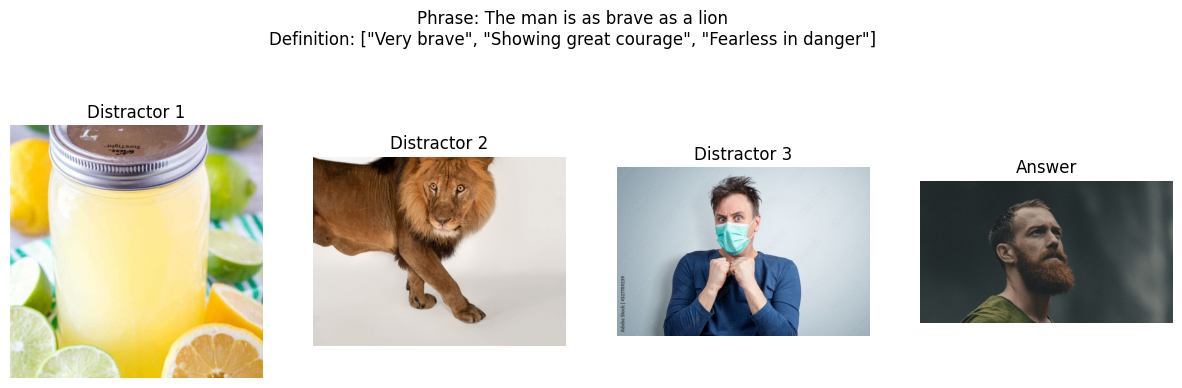

In [18]:
import PIL.Image as Image
import matplotlib.pyplot as plt
import numpy as np
# Set the folder path where images are stored - jpeg format, the image name is the image id
image_folder_path = "../data/irfl/images/" # I couldn't use the IRFL_images dataset directly, cuz the image.filename field didn't exist
complete_detection_dataset_path = os.path.join(datasets_path, "IRFL_complete_detection_tasks_w_all_defs.csv")
complete_detection_task_datasets = pd.read_csv(complete_detection_dataset_path)
def get_image_path_from_folder(image_name, image_folder_path=image_folder_path):
  image_path = image_folder_path + image_name.split(".")[0] + ".jpeg"
  return image_path

def get_image(image_name):
  image_path = get_image_path_from_folder(image_name)
  return Image.open(image_path)

# get first row in the complete_detection_task_datasets dataframe
idx_ = np.random.randint(0, len(complete_detection_task_datasets)-1)
row = complete_detection_task_datasets.iloc[idx_]
distractors = json.loads(row['distractors'])
answer = json.loads(row['answer'])[0]
phrase = row['phrase']
definition = row['definition']

fig, axes = plt.subplots(1, len(distractors) + 1, figsize=(15, 5))
for i, img_id in enumerate(distractors):
    img = get_image(img_id)
    axes[i].imshow(img)
    axes[i].set_title(f"Distractor {i+1}")
    axes[i].axis('off')

img = get_image(answer)
axes[-1].imshow(img)
axes[-1].set_title("Answer")
axes[-1].axis('off')

plt.suptitle(f"Phrase: {phrase}\nDefinition: {definition}")
plt.show()

In [121]:
# Split the dataset into train and test sets based on unique phrases so that the model does not see the same phrase in both sets
complete_d_phrases = complete_datasets_fig_df['phrase'].unique()
complete_ret_phrases = complete_retrieval_task_datasets['phrase'].unique()
complete_det_phrases = complete_detection_task_datasets['phrase'].unique()

# The train is the complete dataset minus the phrases that appear in the detection task dataset
train_phrases = list(set(complete_d_phrases) - set(complete_det_phrases))
test_phrases = list(complete_det_phrases)
train_df = complete_datasets_fig_df[complete_datasets_fig_df['phrase'].isin(train_phrases)]
test_df = complete_detection_task_datasets
len(train_df), len(test_df)

(2938, 810)

In [123]:
# save the updated dataframe to a new csv file
train_path = os.path.join(datasets_path, "IRFL_train_dataset.csv")
train_df.to_csv(train_path, index=False)
test_path = os.path.join(datasets_path, "IRFL_test_detect_dataset.csv")
test_df.to_csv(test_path, index=False)

In [6]:
display(train_df.head()), display(test_df.head())

,phrase,category,source,uuid,figurative_type,definition
0,above board,Figurative,https://www.bbc.com/future/article/20150906-th...,2347455769995818582292464109301538870658385019...,idiom,"['Openly, without deceit', 'Honestly, reputably']"
1,add fuel to the fire,Figurative,https://www.entrepreneur.com/article/238993,8373515052129855505731264934843997844218183589...,idiom,"['To worsen a conflict between people', 'to in..."
2,add fuel to the fire,Figurative,https://www.commisceo-global.com/blog/causes-i...,2944701897566652991415294743036040806258040739...,idiom,"['To worsen a conflict between people', 'to in..."
3,add fuel to the fire,Figurative,https://www.adl.org/resources/blog/new-black-p...,2382205381708037966733438617112387636813898461...,idiom,"['To worsen a conflict between people', 'to in..."
4,add fuel to the fire,Figurative,https://exclusive.multibriefs.com/content/4-qu...,8141677736454292128447148460868091284668316601...,idiom,"['To worsen a conflict between people', 'to in..."


,query,distractors,answer,figurative_type,images_metadata,type,definition,phrase
0,Some people will be fired for incompetence,"[""84352007896950506320882811482278349695560308...","[""63706241105000335873917995039219892466282882...",idiom,"[{""IRFL_id"": ""84352007896950506320882811482278...",figurative,"[""Some people will be fired for incompetence""]",heads will roll
1,Some people will be fired for incompetence,"[""11139640979629227670840685210851097800085639...","[""32967313379712245226124296173499178510479001...",idiom,"[{""IRFL_id"": ""11139640979629227670840685210851...",figurative+literal,"[""Some people will be fired for incompetence""]",heads will roll
2,To begin a festive celebration and rejoicing f...,"[""54601539116562142146404710575883516631923860...","[""10872863681659062591323572608656133400591568...",idiom,"[{""IRFL_id"": ""54601539116562142146404710575883...",figurative,"[""To begin a festive celebration and rejoicing...",kill the fatted calf
3,To begin a festive celebration and rejoicing f...,"[""54601539116562142146404710575883516631923860...","[""10321079079407066016269319155432172715117464...",idiom,"[{""IRFL_id"": ""54601539116562142146404710575883...",figurative,"[""To begin a festive celebration and rejoicing...",kill the fatted calf
4,To begin a festive celebration and rejoicing f...,"[""99143968578258977515069543216750554044633692...","[""27714235957780911615713121412061548157239097...",idiom,"[{""IRFL_id"": ""99143968578258977515069543216750...",figurative,"[""To begin a festive celebration and rejoicing...",kill the fatted calf


(None, None)

In [3]:
!pip install git+https://github.com/openai/CLIP.git --quiet

### Load train and test dataframes and test zero-shot clip

In [16]:
# Load datasets
test_df = pd.read_csv(os.path.join(datasets_path, "IRFL_test_detect_dataset.csv"))
train_df = pd.read_csv(os.path.join(datasets_path, "IRFL_train_dataset.csv"))

In [19]:
import torch
import clip

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess_func = clip.load('ViT-B/32', device=device)

total_parameters = sum(p.numel() for p in model.parameters())
for param in model.parameters():
    param.requires_grad = False

@torch.no_grad()
def get_text_token_embeddings(texts):
    tokens = clip.tokenize(texts, truncate=True).to(device)          # [B, T]

    x = model.token_embedding(tokens).type(model.dtype)              # [B, T, d_model]
    x = x + model.positional_embedding.type(model.dtype)             # [B, T, d_model]

    x = x.permute(1, 0, 2)                                           # [T, B, d_model]
    x = model.transformer(x)
    x = x.permute(1, 0, 2)                                           # [B, T, d_model]

    x = model.ln_final(x)                                            # [B, T, d_model]

    mask = tokens != 0 # [B, T]
    return x.float(), tokens, mask                                     # token-level features (pre-projection)

@torch.no_grad()
def get_clip_txt_vector(text, normalize=True):
    cue_clip_txt = clip.tokenize([text]).to(device)
    
    cue_clip_txt_encoded = model.encode_text(cue_clip_txt)
    
    if normalize:
        cue_clip_txt_encoded /= cue_clip_txt_encoded.norm(dim=-1, keepdim=True)
    return cue_clip_txt_encoded


@torch.no_grad()
def get_vit_patch_embeddings(images):
    """
    images: list[PIL.Image] OR a preprocessed tensor [B, 3, 224, 224]
    returns:
      patch_feats: [B, N, width]   (pre-projection)
      cls_feat:    [B, width]      (pre-projection)
    """
    visual = model.visual

    if isinstance(images, torch.Tensor):
        x = images.to(device)
    elif isinstance(images, list):
        if not all(isinstance(im, Image.Image) for im in images):
            raise ValueError("If images is a list, all elements must be PIL.Image")
        x = torch.stack([preprocess_func(im) for im in images], dim=0).to(device)

    x = x.type(model.dtype)

    # conv1 patchify
    x = visual.conv1(x)                                               # [B, width, grid, grid]
    B, C, Gh, Gw = x.shape
    x = x.reshape(B, C, Gh * Gw).permute(0, 2, 1)                     # [B, N, width]

    # add CLS token
    cls = visual.class_embedding.to(x.dtype)
    cls = cls + torch.zeros(B, 1, x.shape[-1], dtype=x.dtype, device=x.device)
    x = torch.cat([cls, x], dim=1)                                    # [B, 1+N, width]

    # add pos + ln_pre
    x = x + visual.positional_embedding.to(x.dtype)
    x = visual.ln_pre(x)

    # transformer blocks
    x = x.permute(1, 0, 2)                                            # [L, B, width]
    x = visual.transformer(x)
    x = x.permute(1, 0, 2)                                            # [B, 1+N, width]

    # final LN (still pre-projection)
    x = visual.ln_post(x)                                             # [B, 1+N, width]

    cls_feat = x[:, 0, :].float()                                     # [B, width]
    patch_feats = x[:, 1:, :].float()                                 # [B, N, width]
    return patch_feats, cls_feat

@torch.no_grad()
def get_clip_img_vector(img, normalize=True):
    cue_clip_img = preprocess_func(get_image(img)).unsqueeze(0).to(device)
    
    cue_clip_img_encoded = model.encode_image(cue_clip_img)
    
    if normalize:
        cue_clip_img_encoded /= cue_clip_img_encoded.norm(dim=-1, keepdim=True)
    return cue_clip_img_encoded


def get_vectors_similarity(v1, v2):
    similarity = v1.detach().cpu().numpy() @ v2.detach().cpu().numpy().T
    return similarity



# This function will return the matching probability of the phrase and its image.
# If `definitions` are provided, it will concatenate the definitions of the phrase. Only idiom instances pass definitions.
# If you wish to test your model just replace CLIP with the desired model.
def get_phrase_image_similarity_score(phrase, image, definitions, normalize=True):
    if definitions:
        definition_prompt = '.'.join(definitions) + '.'
        phrase_plus_definitions = phrase + '.' + definition_prompt
        phrase_clip_txt_encoded = get_clip_txt_vector(phrase_plus_definitions, normalize=normalize)
    else:
        phrase_clip_txt_encoded = get_clip_txt_vector(phrase, normalize=normalize)
    clip_cand_img_encoded = get_clip_img_vector(image, normalize=normalize)
    cand_txt_img_sim = get_vectors_similarity(phrase_clip_txt_encoded, clip_cand_img_encoded).item()
    return cand_txt_img_sim

### Example of answer image vs distractor images scores wrt the figurative caption

In [9]:
for row in test_df.sample(1).itertuples():
    distractors = json.loads(row.distractors)
    answer = json.loads(row.answer)[0]
    phrase = row.phrase
    definition = json.loads(row.definition)

    # compute text embeddings
    # text_embeds, text_tokens, text_mask = get_text_token_embeddings(phrase)
    # print(f"text embeddings {text_embeds.shape}")
    # print(f"text tokens {text_tokens.shape}")
    # print(f'mask: {text_mask.shape}')

    # compute definition embeddings
    # definition_embeds, definition_tokens, definition_mask = get_text_token_embeddings('.'.join(definition) + '.')
    # print(f"definition embeddings {definition_embeds.shape}")
    # print(f"definition tokens {definition_tokens.shape}")
    # print(f'definition mask: {definition_mask.shape}')
    
    print(f"Phrase: {phrase}")
    print(f"Definitions: {definition}")
    print(f"Answer Image:")
    answer_score = get_phrase_image_similarity_score(phrase, answer, definition)
    print(f"Answer Similarity Score: {answer_score:.4f}")

    # compute patch embeddings
    # image_patch_feats, image_cls_feat = get_vit_patch_embeddings([answer])
    # print(f"Image patch features shape: {image_patch_feats.shape}")
    for i, img_id in enumerate(distractors):
        distractor_score = get_phrase_image_similarity_score(phrase, img_id, definition)
        print(f"Distractor {i+1} Similarity Score: {distractor_score:.4f}")
    print("--------------------------------------------------")

Phrase: heart sank
Definitions: ['A sudden feeling of disappointment', 'An immediate loss of hope', 'A feeling of dread or sadness']
Answer Image:
Answer Similarity Score: 0.2412
Distractor 1 Similarity Score: 0.2025
Distractor 2 Similarity Score: 0.2013
Distractor 3 Similarity Score: 0.1731
--------------------------------------------------


### Compute CLIP's zero-shot performance

In [180]:
def compute_accuracy(test_df, use_definitions=True):
    correct = 0
    total = 0

    for row in test_df.itertuples():
        distractors = json.loads(row.distractors)
        answer = json.loads(row.answer)[0]
        phrase = row.phrase
        definition = json.loads(row.definition)

        scores = []
        for img_id in distractors + [answer]:
            score = get_phrase_image_similarity_score(phrase, img_id, definition if use_definitions else "")
            scores.append((img_id, score))
        
        # Get the image with the highest score
        predicted_img_id, _ = max(scores, key=lambda x: x[1])
        
        if predicted_img_id == answer:
            correct += 1
        total += 1

    accuracy = correct / total if total > 0 else 0
    return accuracy


results_dict_w_def = {'figurative_type': [], 'type': [], 'Accuracy': []}
results_dict_wo_def = {'figurative_type': [], 'type': [], 'Accuracy': []}
for fig_type, gen_type in test_df[['figurative_type', 'type']].drop_duplicates().itertuples(index=False):

    results_dict_w_def['figurative_type'].append(fig_type)
    results_dict_w_def['type'].append(gen_type)

    results_dict_wo_def['figurative_type'].append(fig_type)
    results_dict_wo_def['type'].append(gen_type)
    
    # Calculate accuracy for this category
    category_df = test_df[(test_df['figurative_type'] == fig_type) & (test_df['type'] == gen_type)]

    accuracy = compute_accuracy(category_df)
    accuracy_no_def = compute_accuracy(category_df, use_definitions=False)
    results_dict_w_def['Accuracy'].append(accuracy)
    results_dict_wo_def['Accuracy'].append(accuracy_no_def)
    
    print(f"Category: ({fig_type}, {gen_type}), Accuracy w/ definitions: {100* accuracy:.4f} %")
    print(f"Category: ({fig_type}, {gen_type}), Accuracy w/o definitions: {100* accuracy_no_def:.4f} %")
results_w_defs_dataframe = pd.DataFrame(results_dict_w_def)
results_wo_defs_dataframe = pd.DataFrame(results_dict_wo_def)

Category: (idiom, figurative), Accuracy w/ definitions: 16.0305 %
Category: (idiom, figurative), Accuracy w/o definitions: 5.3435 %
Category: (idiom, figurative+literal), Accuracy w/ definitions: 44.9275 %
Category: (idiom, figurative+literal), Accuracy w/o definitions: 36.2319 %
Category: (metaphor, figurative), Accuracy w/ definitions: 36.0360 %
Category: (metaphor, figurative), Accuracy w/o definitions: 23.4234 %
Category: (simile, figurative), Accuracy w/ definitions: 48.0144 %
Category: (simile, figurative), Accuracy w/o definitions: 45.4874 %


### Pre-extract CLIP text & image embeddings

In [10]:
test_df.columns

Index(['query', 'distractors', 'answer', 'figurative_type', 'images_metadata',
       'type', 'definition', 'phrase'],
      dtype='object')

In [9]:
from tqdm import tqdm
# init train lists
train_images= []
train_phrases, train_phrases_tokens, train_phrases_mask = [], [], []
train_definitions, train_definitions_tokens, train_definitions_mask = [], [], []
train_joint_def_phrases, train_joint_def_phrases_tokens, train_joint_def_phrases_mask = [], [], []
train_figurative_type= []


for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    phrase = row.phrase # phrase text
    image = get_image(row.uuid) # single image for this phrase
    definition = json.loads(row.definition) # definition(s) provided for this phrase
    joint_def_phrase = phrase + '.' + '.'.join(definition) + '.' # concatenate phrase and definitions

    image_embeds, image_cls_feat = get_vit_patch_embeddings([row.uuid])
    phrase_embeds, phrase_tokens, phrase_mask = get_text_token_embeddings(phrase)
    definition_embeds, definition_tokens, definition_mask = get_text_token_embeddings('.'.join(definition) + '.')
    joint_embeds, joint_tokens, joint_mask = get_text_token_embeddings(joint_def_phrase)

    train_images.append(image_embeds)
    train_phrases.append(phrase_embeds)
    train_phrases_tokens.append(phrase_tokens)
    train_phrases_mask.append(phrase_mask)
    train_definitions.append(definition_embeds)
    train_definitions_tokens.append(definition_tokens)
    train_definitions_mask.append(definition_mask)
    train_joint_def_phrases.append(joint_embeds)
    train_joint_def_phrases_tokens.append(joint_tokens)
    train_joint_def_phrases_mask.append(joint_mask)
    train_figurative_type.append(row.figurative_type)

# init test lists
test_answers, test_distractors = [], []
test_phrases, test_phrases_tokens, test_phrases_mask = [], [], []
test_definitions, test_definitions_tokens, test_definitions_mask = [], [], []
test_joint_def_phrases, test_joint_def_phrases_tokens, test_joint_def_phrases_mask = [], [], []
test_figurative_type, test_answer_type = [], []


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    distractors = json.loads(row.distractors)
    answer = json.loads(row.answer)[0]
    phrase = row.phrase
    definition = json.loads(row.definition)
    joint_def_phrase = phrase + '.' + '.'.join(definition) + '.'

    distractor_embeds, _ = get_vit_patch_embeddings(distractors)
    answer_embeds, _ = get_vit_patch_embeddings([answer])
    phrase_embeds, phrase_tokens, phrase_mask = get_text_token_embeddings(phrase)
    definition_embeds, definition_tokens, definition_mask = get_text_token_embeddings('.'.join(definition) + '.')
    joint_embeds, joint_tokens, joint_mask = get_text_token_embeddings(joint_def_phrase)

    test_distractors.append(distractor_embeds)
    test_answers.append(answer_embeds)
    test_phrases.append(phrase_embeds)
    test_phrases_tokens.append(phrase_tokens)
    test_phrases_mask.append(phrase_mask)
    test_definitions.append(definition_embeds)
    test_definitions_tokens.append(definition_tokens)
    test_definitions_mask.append(definition_mask)
    test_joint_def_phrases.append(joint_embeds)
    test_joint_def_phrases_tokens.append(joint_tokens)
    test_joint_def_phrases_mask.append(joint_mask)
    test_figurative_type.append(row.figurative_type)
    test_answer_type.append(row.type)

100%|██████████| 810/810 [01:26<00:00,  9.37it/s]


### Concat in single tensor

In [10]:
concat_ = lambda x: torch.cat(x, dim=0)

# apply concat to train data
train_images = concat_(train_images)
train_phrases = concat_(train_phrases)
train_phrases_tokens = concat_(train_phrases_tokens)
train_phrases_mask = concat_(train_phrases_mask)
train_definitions = concat_(train_definitions)
train_definitions_tokens = concat_(train_definitions_tokens)
train_definitions_mask = concat_(train_definitions_mask)
train_joint_def_phrases = concat_(train_joint_def_phrases)
train_joint_def_phrases_tokens = concat_(train_joint_def_phrases_tokens)
train_joint_def_phrases_mask = concat_(train_joint_def_phrases_mask)

# apply concat to test data
test_answers = concat_(test_answers)
test_phrases = concat_(test_phrases)
test_phrases_tokens = concat_(test_phrases_tokens)
test_phrases_mask = concat_(test_phrases_mask)
test_definitions = concat_(test_definitions)
test_definitions_tokens = concat_(test_definitions_tokens)
test_definitions_mask = concat_(test_definitions_mask)
test_joint_def_phrases = concat_(test_joint_def_phrases)
test_joint_def_phrases_tokens = concat_(test_joint_def_phrases_tokens)
test_joint_def_phrases_mask = concat_(test_joint_def_phrases_mask)

test_distractors = concat_([distractor.unsqueeze(0) for distractor in test_distractors])
 

In [12]:
# print shapes
print(f"Train images shape: {train_images.shape}")
print(f"Train phrases shape: {train_phrases.shape}")
print(f"Train definitions shape: {train_definitions.shape}")  
print(f"Train joint def+phrases shape: {train_joint_def_phrases.shape}")
print("--------------------------------------------------")
print(f"Test answers shape: {test_answers.shape}")
print(f"Test distractors shape: {test_distractors.shape}")
print(f"Test phrases shape: {test_phrases.shape}")
print(f"Test definitions shape: {test_definitions.shape}")  
print(f"Test joint def+phrases shape: {test_joint_def_phrases.shape}")

Train images shape: torch.Size([2938, 49, 768])
Train phrases shape: torch.Size([2938, 77, 512])
Train definitions shape: torch.Size([2938, 77, 512])
Train joint def+phrases shape: torch.Size([2938, 77, 512])
--------------------------------------------------
Test answers shape: torch.Size([810, 49, 768])
Test distractors shape: torch.Size([810, 3, 49, 768])
Test phrases shape: torch.Size([810, 77, 512])
Test definitions shape: torch.Size([810, 77, 512])
Test joint def+phrases shape: torch.Size([810, 77, 512])


In [13]:
# save the tensors to a file
torch.save({
    'train_images': train_images,
    'train_phrases': train_phrases,
    'train_phrases_tokens': train_phrases_tokens,
    'train_phrases_mask': train_phrases_mask,
    'train_definitions': train_definitions,
    'train_definitions_tokens': train_definitions_tokens,
    'train_definitions_mask': train_definitions_mask,
    'train_joint_def_phrases': train_joint_def_phrases,
    'train_joint_def_phrases_tokens': train_joint_def_phrases_tokens,
    'train_joint_def_phrases_mask': train_joint_def_phrases_mask
}, os.path.join(datasets_path, 'IRFL_train_tensors.pt'))


torch.save({
    'test_answers': test_answers,
    'test_distractors': test_distractors,
    'test_phrases': test_phrases,
    'test_phrases_tokens': test_phrases_tokens,
    'test_phrases_mask': test_phrases_mask,
    'test_definitions': test_definitions,
    'test_definitions_tokens': test_definitions_tokens,
    'test_definitions_mask': test_definitions_mask,
    'test_joint_def_phrases': test_joint_def_phrases,
    'test_joint_def_phrases_tokens': test_joint_def_phrases_tokens,
    'test_joint_def_phrases_mask': test_joint_def_phrases_mask,
}, os.path.join(datasets_path, 'IRFL_test_tensors.pt'))


### Define Augmentations

Original Phrase: come a cropper
Augmented Phrase: ['come a cropper', 'text: come a cropper', 'caption: come a cropper', 'description: come a cropper', 'phrase: come a cropper', 'query: come a cropper', 'label: come a cropper']
--------------------------------------------------
Original Definition: ['To suffer some accident or misfortune', 'to fail']
Augmented Definition: ["['To suffer some accident or misfortune', 'to fail']", "definition: ['To suffer some accident or misfortune', 'to fail']", "meaning: ['To suffer some accident or misfortune', 'to fail']", "explanation: ['To suffer some accident or misfortune', 'to fail']", "description: ['To suffer some accident or misfortune', 'to fail']", "['To suffer some accident or misfortune','to fail']", "definition: ['To suffer some accident or misfortune','to fail']", "meaning: ['some accident misfortune','to fail']", "explanation: ['To suffer some accident or misfortune','fail']", "description: ['To suffer some or misfortune','to fail']"]
-

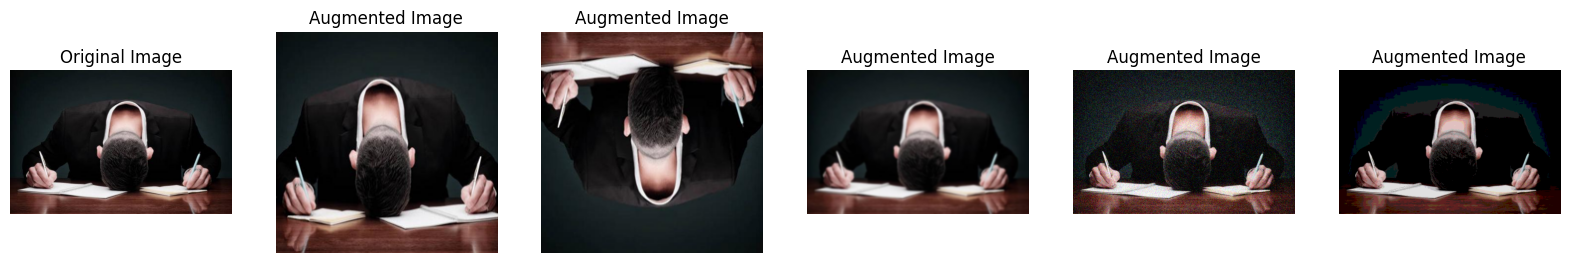

In [23]:
def_augment = make_definition_augmentation_function()
image_augment = make_image_augmentation_function()
phrase_augment = make_text_augmentation_function()

# visualize some augmentation examples
for example in train_df.sample(1).itertuples():
    phrase = example.phrase
    definition = json.loads(example.definition)
    image = get_image(example.uuid)

    augmented_phrase = phrase_augment(phrase)
    augmented_definition = def_augment(definition)
    augmented_images = image_augment(image)

    print(f"Original Phrase: {phrase}")
    print(f"Augmented Phrase: {augmented_phrase}")
    print("--------------------------------------------------")
    print(f"Original Definition: {definition}")
    print(f"Augmented Definition: {augmented_definition}")
    print("--------------------------------------------------")
    plt.figure(figsize=(20, 6))
    plt.subplot(1, len(augmented_images) + 1, 1)
    plt.title("Original Image")
    plt.imshow(image)
    plt.axis('off')

    for i in range(len(augmented_images)):
        plt.subplot(1, len(augmented_images) + 1, i + 2)
        plt.title("Augmented Image")
        plt.imshow(augmented_images[i])
        plt.axis('off')

    plt.show()

### Create and augmented dataset
This is primarily done to reduce the training duration. We pre-augment all the images and phrases with all the possible augmentations and parse them though the model.
During training for each image (text, etc.), we will randomly choose one of the possible, already augmented embeddings.

In [29]:
from tqdm import tqdm
# init train lists
train_images_aug= []
train_phrases_aug, train_phrases_tokens_aug, train_phrases_mask_aug = [], [], []
train_definitions_aug, train_definitions_tokens_aug, train_definitions_mask_aug = [], [], []
train_joint_def_phrases_aug, train_joint_def_phrases_tokens_aug, train_joint_def_phrases_mask_aug = [], [], []
train_figurative_type_aug= []


for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    torch.cuda.empty_cache()
    phrase = row.phrase # phrase text
    image = get_image(row.uuid) # single image for this phrase
    definition = json.loads(row.definition) # definition(s) provided for this phrase

    # Augment the image, phrase, and definitions
    augmented_images = image_augment(image)
    augmented_phrases = phrase_augment(phrase)
    augmented_definitions = def_augment(definition)
    joint_def_phrase_aug = []
    for aug_phrase in augmented_phrases:
        for aug_def in augmented_definitions:
            joint_def_phrase_aug.append(aug_phrase + '.' + '.'.join(aug_def) + '.')

    image_embeds, image_cls_feat = get_vit_patch_embeddings(augmented_images)
    phrase_embeds, phrase_tokens, phrase_mask = get_text_token_embeddings(augmented_phrases)
    definition_embeds, definition_tokens, definition_mask = get_text_token_embeddings(augmented_definitions)
    joint_embeds, joint_tokens, joint_mask = get_text_token_embeddings(joint_def_phrase_aug)

    train_images_aug.append(image_embeds)
    train_phrases_aug.append(phrase_embeds)
    train_phrases_tokens_aug.append(phrase_tokens)
    train_phrases_mask_aug.append(phrase_mask)
    train_definitions_aug.append(definition_embeds)
    train_definitions_tokens_aug.append(definition_tokens)
    train_definitions_mask_aug.append(definition_mask)
    train_joint_def_phrases_aug.append(joint_embeds)
    train_joint_def_phrases_tokens_aug.append(joint_tokens)
    train_joint_def_phrases_mask_aug.append(joint_mask)
    train_figurative_type_aug.append(row.figurative_type)

# init test lists
test_answers_aug= []
test_phrases_aug, test_phrases_tokens_aug, test_phrases_mask_aug = [], [], []
test_definitions_aug, test_definitions_tokens_aug, test_definitions_mask_aug = [], [], []
test_joint_def_phrases_aug, test_joint_def_phrases_tokens_aug, test_joint_def_phrases_mask_aug = [], [], []
test_figurative_type_aug, test_answer_type_aug = [], []


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    distractors = json.loads(row.distractors)
    answer = json.loads(row.answer)[0]
    phrase = row.phrase
    definition = json.loads(row.definition)
    joint_def_phrase = phrase + '.' + '.'.join(definition) + '.'

    # Augment the answer, phrase, and definitions
    augmented_answer = image_augment(get_image(answer))
    augmented_phrases = phrase_augment(phrase)
    augmented_definitions = def_augment(json.dumps(definition))
    joint_def_phrase_aug = []
    for aug_phrase in augmented_phrases:
        for aug_def in augmented_definitions:
            joint_def_phrase_aug.append(aug_phrase + '.' + '.'.join(aug_def) + '.')
    
    answer_embeds, _ = get_vit_patch_embeddings(augmented_answer)
    phrase_embeds, phrase_tokens, phrase_mask = get_text_token_embeddings(augmented_phrases)
    definition_embeds, definition_tokens, definition_mask = get_text_token_embeddings(augmented_definitions)
    joint_embeds, joint_tokens, joint_mask = get_text_token_embeddings(joint_def_phrase_aug)

    test_answers_aug.append(answer_embeds)
    test_phrases_aug.append(phrase_embeds)
    test_phrases_tokens_aug.append(phrase_tokens)
    test_phrases_mask_aug.append(phrase_mask)
    test_definitions_aug.append(definition_embeds)
    test_definitions_tokens_aug.append(definition_tokens)
    test_definitions_mask_aug.append(definition_mask)
    test_joint_def_phrases_aug.append(joint_embeds)
    test_joint_def_phrases_tokens_aug.append(joint_tokens)
    test_joint_def_phrases_mask_aug.append(joint_mask)
    test_figurative_type_aug.append(row.figurative_type)
    test_answer_type_aug.append(row.type)

100%|██████████| 810/810 [03:53<00:00,  3.46it/s]


In [30]:
print(train_images_aug[0].shape, len(train_images_aug), train_phrases_aug[0].shape, len(train_phrases_aug), train_definitions_aug[1].shape, len(train_definitions_aug))
print(test_answers_aug[0].shape, len(test_answers_aug), test_phrases_aug[0].shape, len(test_phrases_aug), test_definitions_aug[9].shape, len(test_definitions_aug))


concat_aug_ = lambda x: torch.cat([x_i.unsqueeze(0) for x_i in x], dim=0)

# apply concat to train data
train_images_aug = concat_aug_(train_images_aug)
train_phrases_aug = concat_aug_(train_phrases_aug)
train_phrases_tokens_aug = concat_aug_(train_phrases_tokens_aug)
train_phrases_mask_aug = concat_aug_(train_phrases_mask_aug)

# apply concat to test data
test_answers_aug = concat_aug_(test_answers_aug)
test_phrases_aug = concat_aug_(test_phrases_aug)
test_phrases_tokens_aug = concat_aug_(test_phrases_tokens_aug)
test_phrases_mask_aug = concat_aug_(test_phrases_mask_aug)

torch.Size([5, 49, 768]) 2938 torch.Size([7, 77, 512]) 2938 torch.Size([10, 77, 512]) 2938
torch.Size([5, 49, 768]) 810 torch.Size([7, 77, 512]) 810 torch.Size([7, 77, 512]) 810


In [31]:

print(f"Train images augmented shape: {train_images_aug.shape}")
print(f"Train phrases augmented shape: {train_phrases_aug.shape}")
print(f"Train phrases tokens augmented shape: {train_phrases_tokens_aug.shape}")
print(f"Train phrases mask augmented shape: {train_phrases_mask_aug.shape}")
print("--------------------------------------------------")
print(f"Test answers augmented shape: {test_answers_aug.shape}")
print(f"Test phrases augmented shape: {test_phrases_aug.shape}")
print(f"Test phrases tokens augmented shape: {test_phrases_tokens_aug.shape}")
print(f"Test phrases mask augmented shape: {test_phrases_mask_aug.shape}")

Train images augmented shape: torch.Size([2938, 5, 49, 768])
Train phrases augmented shape: torch.Size([2938, 7, 77, 512])
Train phrases tokens augmented shape: torch.Size([2938, 7, 77])
Train phrases mask augmented shape: torch.Size([2938, 7, 77])
--------------------------------------------------
Test answers augmented shape: torch.Size([810, 5, 49, 768])
Test phrases augmented shape: torch.Size([810, 7, 77, 512])
Test phrases tokens augmented shape: torch.Size([810, 7, 77])
Test phrases mask augmented shape: torch.Size([810, 7, 77])


### Save the augmented dataset

In [57]:

torch.save({
    'train_images_aug': train_images_aug.half(),
    'train_phrases_aug': train_phrases_aug.half(),
    'train_phrases_mask_aug': train_phrases_mask_aug.half(),
    'train_definitions_aug': [temp_aug.half() for temp_aug in train_definitions_aug],
    'train_definitions_mask_aug': [temp_mask.half() for temp_mask in train_definitions_mask_aug],
    'train_joint_def_phrases_aug': [train_joint_def_phrases_aug_i.half() for train_joint_def_phrases_aug_i in train_joint_def_phrases_aug],
    'train_joint_def_phrases_mask_aug': [train_joint_def_phrases_mask_aug_i.half() for train_joint_def_phrases_mask_aug_i in train_joint_def_phrases_mask_aug]
}, os.path.join(datasets_path, 'IRFL_train_tensors_aug.pt'))

torch.save({
    'test_answers_aug': test_answers_aug.half(),
    'test_phrases_aug': test_phrases_aug.half(),
    'test_phrases_mask_aug': test_phrases_mask_aug.half(),
    'test_definitions_aug': [temp_aug.half() for temp_aug in test_definitions_aug],
    'test_definitions_mask_aug': [temp_mask.half() for temp_mask in test_definitions_mask_aug],
    'test_joint_def_phrases_aug': [test_joint_def_phrases_aug_i.half() for test_joint_def_phrases_aug_i in test_joint_def_phrases_aug],
    'test_joint_def_phrases_mask_aug': [test_joint_def_phrases_mask_aug_i.half() for test_joint_def_phrases_mask_aug_i in test_joint_def_phrases_mask_aug],
}, os.path.join(datasets_path, 'IRFL_test_tensors_aug.pt'))


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.03 GiB. GPU 0 has a total capacity of 79.25 GiB of which 9.94 MiB is free. Including non-PyTorch memory, this process has 79.23 GiB memory in use. Of the allocated memory 73.81 GiB is allocated by PyTorch, and 4.92 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### Create a dataset as follows

In [58]:
# Load and test data
torch.cuda.empty_cache()
total_train_data = torch.load(os.path.join(datasets_path, 'IRFL_train_tensors.pt'), map_location="cpu")
total_test_data = torch.load(os.path.join(datasets_path, 'IRFL_test_tensors.pt'), map_location="cpu")

In [78]:
torch.cuda.empty_cache()
total_train_data_aug = torch.load(os.path.join(datasets_path, 'IRFL_train_tensors_aug.pt'), map_location="cpu")

total_test_data_aug = torch.load(os.path.join(datasets_path, 'IRFL_test_tensors_aug.pt'), map_location="cpu")

train_dataset = IRFLDataset(total_data= {
    "images": total_train_data['train_images'],
    "texts": total_train_data['train_phrases'],
    "pad_masks": total_train_data['train_phrases_mask'],
    "definitions": total_train_data['train_definitions'],
    "definitions_mask": total_train_data['train_definitions_mask'],

    # Augmented data
    "images_aug": total_train_data_aug['train_images_aug'],
    "texts_aug": total_train_data_aug['train_phrases_aug'],
    "pad_masks_aug": total_train_data_aug['train_phrases_mask_aug'],
    "definitions_aug": total_train_data_aug['train_definitions_aug'],
    "definitions_mask_aug": total_train_data_aug['train_definitions_mask_aug']
}, num_modalities= 3)

In [79]:
test_dataset = IRFLDataset(total_data= {
    "images": total_test_data['test_answers'],
    "distractors": total_test_data['test_distractors'],
    "texts": total_test_data['test_phrases'],
    "pad_masks": total_test_data['test_phrases_mask'],
    "definitions": total_test_data['test_definitions'],
    "definitions_mask": total_test_data['test_definitions_mask'],
    # Augmented data
    "images_aug": total_test_data_aug['test_answers_aug'],
    "texts_aug": total_test_data_aug['test_phrases_aug'],
    "pad_masks_aug": total_test_data_aug['test_phrases_mask_aug'],
    "definitions_aug": total_test_data_aug['test_definitions_aug'],
    "definitions_mask_aug": total_test_data_aug['test_definitions_mask_aug'],
}, num_modalities= 3, data_type='test')

### Define data loaders

In [99]:
from training.train_repercent import make_dataloaders, make_model
from src.models.repercent import RePercENT, DisenLoss
import yaml


BATCH_SIZE = 32

train_loader, test_loader = make_dataloaders(train_dataset, test_dataset, batch_size= BATCH_SIZE)

with open('../configs/data/irfl_data.yaml', 'r') as f:
    data_config = yaml.safe_load(f)
with open('../configs/model/repercent_irfl.yaml', 'r') as f:
    model_config = yaml.safe_load(f)
with open('../configs/training/train_synthetic_3m.yaml', 'r') as f:
    training_config = yaml.safe_load(f)


disenEncoders = [make_model(model_config, data_config, modality=m + 1, M=data_config["create_data"]["M"]) for m in range(data_config["create_data"]["M"])]
model = RePercENT(M=data_config["create_data"]["M"],
                disenEncoder=disenEncoders,
                recon= training_config["disen_loss"]["recon"],
                disen_mapping=model_config["repercent"]["disen_mapping"]).to(device)

disen_loss = DisenLoss(alpha=training_config["disen_loss"]["alpha"],
                    lmd=training_config["disen_loss"]["lmd"],
                    lmd_end_value=training_config["disen_loss"]["lmd_end_value"],
                    M=data_config["create_data"]["M"],
                    recon= training_config["disen_loss"]["recon"])

Initializing Perceiver with Mixture of Experts FeedForward layers with 4 experts.
input channels: 2048, latent dim: 512, num latents: 4
Initializing Perceiver with Mixture of Experts FeedForward layers with 4 experts.
input channels: 2048, latent dim: 512, num latents: 4
Initializing Perceiver with Mixture of Experts FeedForward layers with 4 experts.
input channels: 2048, latent dim: 512, num latents: 4
RePercENT model initialized with latent dimension: 512, sequence dimension: 2048


In [ ]:
# for _iter in range(epochs):
#     # Initialize epoch loss trackers
#     epoch_loss = 0.0
#     epoch_ortho_loss = 0.0
#     epoch_unique_loss = 0.0
#     epoch_shared_loss = 0.0
    
#     model.train()
#     print(f"----- Epoch: {_iter + 1} / {epochs} -----")
#     # Training phase
#     for batch_idx, (X, labels_u, labels_s, _, _) in enumerate(train_loader):
#         temp_b = X[0].shape[0]
#         X = [X[m].to(device) for m in range(M)]

#         # Augment data
#         X_aug = [GenerateData.augment_data(X[m], aug_type="random") for m in range(M)]
        
#         loss, loss_logs = train_loop(X, X_aug, model, optimizer, disen_loss)

#         # Track losses
#         epoch_loss += loss.item() / temp_b
#         epoch_ortho_loss += loss_logs['ortho'] / temp_b
#         epoch_unique_loss += loss_logs['unique'] / temp_b
#         epoch_shared_loss += loss_logs['shared'] / temp_b
        
#     # Epoch statistics
#     avg_epoch_loss = epoch_loss / len(train_loader)
#     avg_ortho_loss = epoch_ortho_loss / len(train_loader)
#     avg_unique_loss = epoch_unique_loss / len(train_loader)
#     avg_shared_loss = epoch_shared_loss / len(train_loader)